# Lab: Neural Network for Binary Classification (Diabetes Prediction)

In this lab, you will:

- Work with the **Pima Indians Diabetes** dataset (medical measurements).
- Build a small **neural network** in TensorFlow/Keras.
- Predict whether a person has **diabetes (1) or not (0)**.
- Evaluate the model using **accuracy** (and optionally confusion matrix).

We will:

- Load the dataset from a public CSV URL.
- Split into **train** and **test** sets.
- Build a `Sequential` model with `Dense` layers and a sigmoid output.

This is your first full **classification neural network** on tabular data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

plt.style.use("seaborn-v0_8-whitegrid")

# Load Pima Indians Diabetes dataset
csv_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree",
    "age",
    "outcome",  # 0 = no diabetes, 1 = diabetes
]

df = pd.read_csv(csv_url, header=None, names=column_names)

df.head()


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Task 1 – Basic understanding of the dataset

Using the DataFrame `df`:

1. Print the **shape** (rows, columns).
2. Use `info()` to see column types and non-null counts.
3. Use `describe()` to see basic statistics.

👉 Fill in the next cell.


In [ ]:
# TASK 1: basic understanding of df

# 1. Print shape
print("Shape:", df.____)      # TODO: attribute for shape

# 2. Info
print("\nInfo:")
df.____()                     # TODO: method to show info

# 3. Describe
print("\nDescribe:")
df.____()                     # TODO: method for summary stats


In [2]:
# TASK 1: basic understanding of df

# 1. Print shape
print("Shape:", df.shape)

# 2. Info
print("\nInfo:")
df.info()

# 3. Describe
print("\nDescribe:")
df.describe()

Shape: (768, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pregnancies        768 non-null    int64  
 1   glucose            768 non-null    int64  
 2   blood_pressure     768 non-null    int64  
 3   skin_thickness     768 non-null    int64  
 4   insulin            768 non-null    int64  
 5   bmi                768 non-null    float64
 6   diabetes_pedigree  768 non-null    float64
 7   age                768 non-null    int64  
 8   outcome            768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Describe:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2 – Separate features and target

- Features (inputs): all columns **except** `outcome`.
- Target (label): the `outcome` column (0 or 1).

👉 In the next cell:

1. Define `feature_cols` as a list of all column names except `"outcome"`.
2. Set `target_col = "outcome"`.
3. Create `X` and `y` as NumPy arrays.


In [ ]:
# TASK 2: define X and y

# 1. Feature columns (all except 'outcome')
feature_cols = [____]   # TODO: list of feature column names or df.columns[:-1].tolist()
target_col = "____"     # TODO: "outcome"

# 2. Extract X and y
X = df[feature_cols].values.astype("float32")
y = df[target_col].values.astype("float32")

X.shape, y.shape

In [3]:
# TASK 2: define X and y

# 1. Feature columns (all except 'outcome')
feature_cols = df.columns[:-1].tolist()
target_col = "outcome"

# 2. Extract X and y
X = df[feature_cols].values.astype("float32")
y = df[target_col].values.astype("float32")

X.shape, y.shape


((768, 8), (768,))

## Task 3 – Train/test split

We split the data into:

- 80% training
- 20% testing

We also use `stratify=y` to keep the ratio of 0/1 similar in both sets.

👉 Complete the `train_test_split` call in the next cell.


In [ ]:
# TASK 3: split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=____,      # TODO: 0.2
    random_state=42,
    stratify=____,       # TODO: y
)

X_train.shape, X_test.shape


In [4]:
# TASK 3: split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape


((614, 8), (154, 8))

## Task 4 – Build a neural network classifier

We will build a small feedforward neural network:

- Input layer: number of features (here 8).
- Hidden layers: 1–2 `Dense` layers with ReLU.
- Output layer: 1 neuron with **sigmoid** activation (probability of diabetes).

Example structure:

- Dense(16, activation="relu")
- Dense(8, activation="relu")
- Dense(1, activation="sigmoid")

👉 In the next cell, create this model using `keras.Sequential`.


In [ ]:
# TASK 4: build the neural network classifier

model = keras.Sequential([
    layers.Input(shape=(____,)),           # TODO: number of input features
    layers.Dense(____, activation="relu"), # TODO: units, e.g. 16
    layers.Dense(____, activation="relu"), # TODO: units, e.g. 8
    layers.Dense(1, activation="____"),    # TODO: "sigmoid"
])

model.summary()


In [6]:
# TASK 4: build the neural network classifier

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # 8 features
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## Task 5 – Compile the model

For binary classification, we will use:

- Loss: `"binary_crossentropy"`
- Optimizer: Adam (learning rate 0.001 or 0.0005)
- Metric: `"accuracy"`

👉 Fill in the compilation step in the next cell.


In [ ]:
# TASK 5: compile the model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=____),  # TODO: e.g. 0.001
    loss="____",                                         # TODO: "binary_crossentropy"
    metrics=["____"],                                    # TODO: "accuracy"
)


In [7]:
# TASK 5: compile the model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


## Task 6 – Train the neural network

Now we train the model on `X_train`, `y_train`.

Suggestions:

- epochs: 50–100
- batch_size: 32
- validation_split: 0.2

👉 Complete the training code in the next cell.


In [ ]:
# TASK 6: train the model

history = model.fit(
    X_train,
    y_train,
    epochs=____,        # TODO: e.g. 75
    batch_size=____,    # TODO: e.g. 32
    validation_split=0.2,
    verbose=1,
)

print("Training complete.")


In [9]:
# TASK 6: train the model

history = model.fit(
    X_train,
    y_train,
    epochs=75,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
)

print("Training complete.")


Training complete.


## Task 7 – Evaluate on the test set

We want to know how well the model performs on **unseen data**.

Steps:

1. Use `model.evaluate(X_test, y_test)` to get loss and accuracy.
2. Get predicted probabilities with `model.predict(X_test)`.
3. Convert probabilities to class labels (0 or 1) using a threshold of 0.5.
4. Compute accuracy again with `accuracy_score`.

👉 Complete the code in the next cell.


In [ ]:
# TASK 7: evaluation on test set

# 1. Evaluate with Keras
test_loss, test_acc = model.evaluate(____, ____, verbose=0)  # TODO: X_test, y_test
print(f"Test accuracy (from Keras): {test_acc:.3f}")

# 2. Predicted probabilities
y_test_proba = model.predict(____)  # TODO: X_test

# 3. Convert probabilities to class labels (0 or 1)
y_test_pred = (y_test_proba >= 0.5).astype(int).reshape(-1)

# 4. Accuracy with sklearn
acc = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy (from sklearn): {acc:.3f}")


In [10]:
# TASK 7: evaluation on test set

# 1. Evaluate with Keras
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (from Keras): {test_acc:.3f}")

# 2. Predicted probabilities
y_test_proba = model.predict(X_test)

# 3. Convert probabilities to class labels (0 or 1)
y_test_pred = (y_test_proba >= 0.5).astype(int).reshape(-1)

# 4. Accuracy with sklearn
acc = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy (from sklearn): {acc:.3f}")


Test accuracy (from Keras): 0.649
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Test accuracy (from sklearn): 0.649


## (Optional) Task 8 – Confusion matrix

A confusion matrix tells us:

- True Negatives (TN): predicted 0, actually 0.
- True Positives (TP): predicted 1, actually 1.
- False Positives (FP): predicted 1, actually 0.
- False Negatives (FN): predicted 0, actually 1.

👉 In the next cell, compute and print the confusion matrix.


In [ ]:
# OPTIONAL TASK 8: confusion matrix

cm = confusion_matrix(____, ____)  # TODO: y_test, y_test_pred
cm


In [11]:
# OPTIONAL TASK 8: confusion matrix

cm = confusion_matrix(y_test, y_test_pred)
cm


array([[100,   0],
       [ 54,   0]])

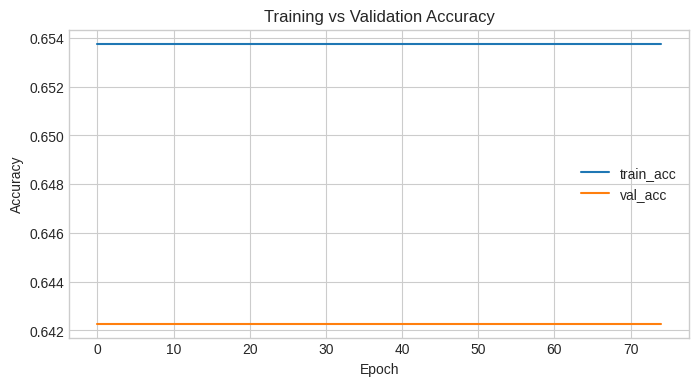

In [12]:
# OPTIONAL: plot training vs validation accuracy

history_dict = history.history

plt.figure(figsize=(8, 4))
plt.plot(history_dict["accuracy"], label="train_acc")
plt.plot(history_dict["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


## Lab wrap-up

In this lab, you:

- Loaded a real **binary classification** dataset (diabetes yes/no).
- Separated features and target.
- Split data into **train** and **test** sets.
- Built a small **neural network classifier** in TensorFlow/Keras.
- Trained it with `binary_crossentropy` and measured **accuracy**.
- (Optionally) looked at a **confusion matrix** and training curves.

You can now try:

- Changing the network size (more/fewer units).
- Changing the number of epochs or learning rate.
- Adding/removing layers and seeing how accuracy changes.


## Saving the model (for using in apps later)

If you want to use this neural network in a small app (e.g. Streamlit),
you can save it to your current folder and load it later.

Run the next cell once to save:


In [14]:
# Save the trained model in the current directory
model.save("diabetes_model.keras")

print("Model saved as folder 'diabetes_model.keras' in this directory.")


Model saved as folder 'diabetes_model.keras' in this directory.


In [15]:
from pathlib import Path
import os

print("CWD:", os.getcwd())
p = Path("diabetes_model.keras").resolve()
print("Expected path:", p)
print("Exists:", p.exists())

CWD: /content
Expected path: /content/diabetes_model.keras
Exists: True


In [16]:
from pathlib import Path

save_dir = Path(r"d:\Coding_Work\Tensorflow event\Final_Notebook\models")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "diabetes_model.keras"
model.save(model_path)

print(f"Model saved at: {model_path}")
print("Exists:", model_path.exists())

Model saved at: d:\Coding_Work\Tensorflow event\Final_Notebook\models/diabetes_model.keras
Exists: True


In [17]:
from google.colab import files
files.download('/content/diabetes_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# 1) Verify where model is in Colab VM
from pathlib import Path
import os

candidates = [
    Path("/content/diabetes_model.keras"),
    Path("diabetes_model.keras").resolve(),
    Path("/content/models/diabetes_model.keras"),
]
for p in candidates:
    print(p, "=>", p.exists())
print("CWD:", os.getcwd())

/content/diabetes_model.keras => True
/content/diabetes_model.keras => True
/content/models/diabetes_model.keras => False
CWD: /content


In [19]:
# 2) Force-save to /content and download
model.save("/content/diabetes_model.keras")

from google.colab import files
files.download("/content/diabetes_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>